# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

==================== 步骤一：数据导入（部分） ====================
客户信用记录:


,客户号,客户姓名,性别,年龄_连续,婚姻状态,户籍,教育程度,居住类型,职业类别,工作年限,个人收入_连续,保险缴纳,车辆情况,信用总评分,信用等级,额度,审批结果
0,999993839040,anon_S3866,男,34,未婚,宁夏,本科,租房,外资企业,11,53040,有,无,60,D-风险客户,10000,0-通过
1,999993839119,anon_S3873,男,34,已婚,山西,本科,租房,私营企业,11,53060,有,无,60,D-风险客户,10000,0-通过



==================== 步骤二：数据合并与清洗 ====================
合并后数据缺失值总览：
清洗后剩余数据量：5954
✅ **审批结果类别分布检查**:
审批结果
0-通过    5954
Name: count, dtype: int64

==================== 步骤三：特征工程 ====================
年龄分组完成。
目标变量 'target'（审批通过=1，不通过=0）构造完成。
分类特征独热编码完成。

==================== 步骤四：决策树分析信用等级 ====================
决策树准确率: 1.0000


C:\Users\26076\AppData\Local\Temp\ipykernel_40948\1555927463.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged[col].fillna(df_merged[col].median(), inplace=True)
C:\Users\26076\AppData\Local\Temp\ipykernel_40948\1555927463.py:70: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

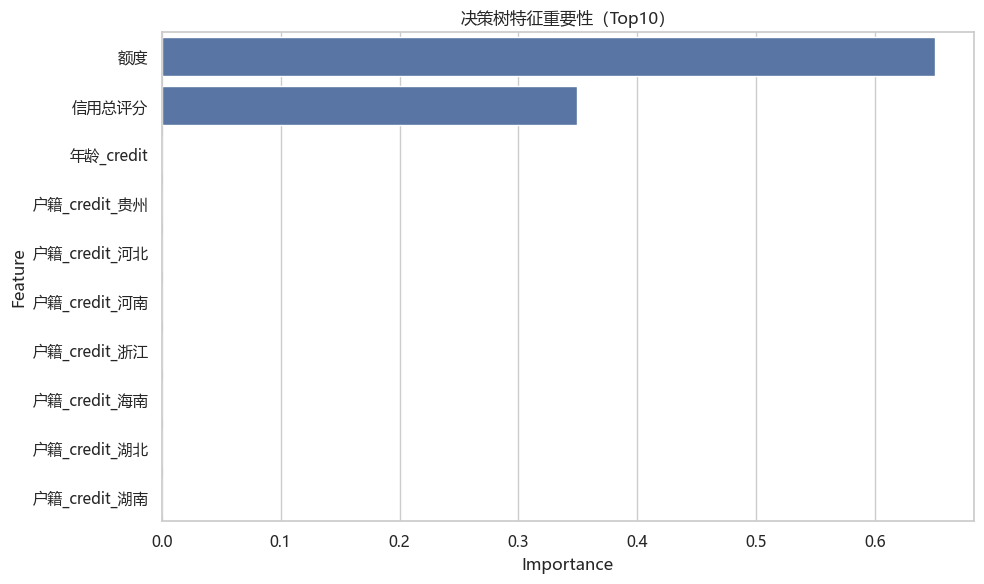

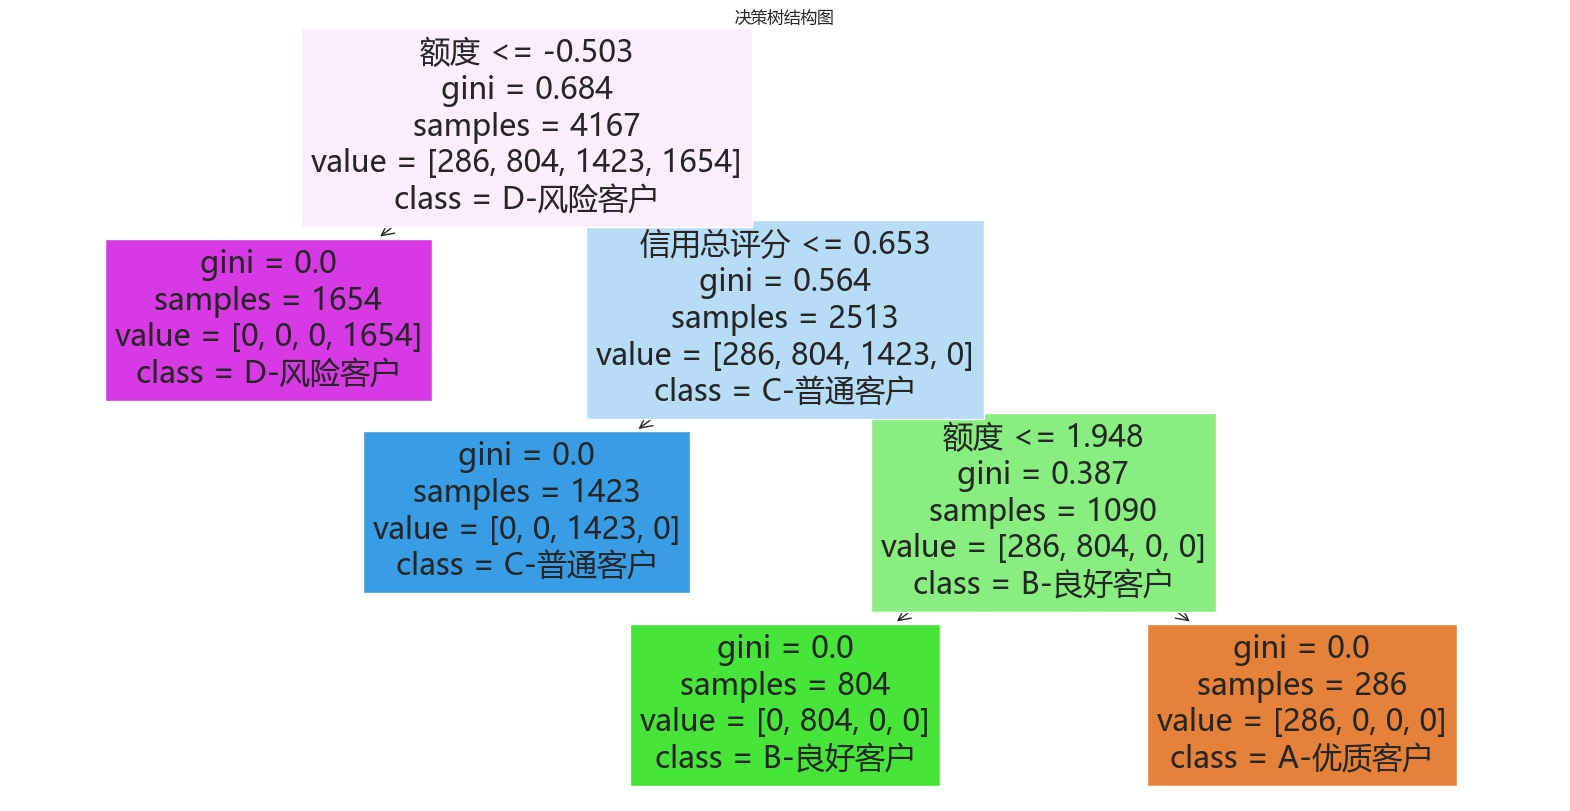


==================== 步骤五：K-Means 客户分群 ====================
K-Means 聚类轮廓系数: 0.881


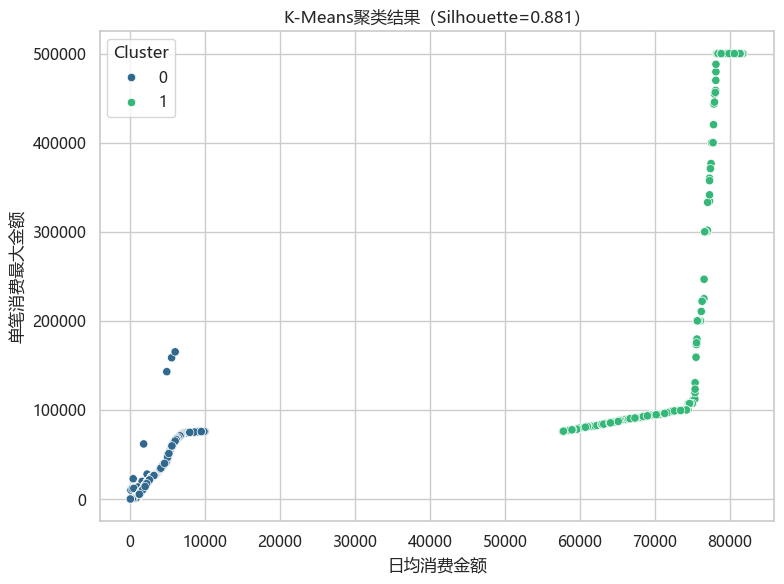


==================== 步骤六：逻辑回归 & SVM 分析申请成功 (下采样优化) ====================
目标变量 'target' (0/1) 最终类别分布：
target
1    5954
Name: count, dtype: int64

🚨 致命错误：数据清洗已做到最大限度保留，此问题极可能源于 **原始数据中负样本缺失**。请检查源文件。


ValueError: The target 'y' needs to have more than 1 class. Got 1 class instead

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid") 
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi', 'Arial Unicode MS', 'sans-serif'] 
plt.rcParams['axes.unicode_minus'] = False 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, silhouette_score, classification_report, confusion_matrix, roc_curve, auc
from mlxtend.frequent_patterns import apriori, association_rules
from IPython.display import display
from imblearn.under_sampling import RandomUnderSampler 

# 数据导入 
base_path = r'E:/Demo/python/银行信用卡欺诈与拖欠行为分析/data/'
df_credit = pd.read_excel(base_path + '数据-客户信用记录.xlsx')
df_apply = pd.read_excel(base_path + '数据-申请客户信息.xlsx')
df_consume = pd.read_excel(base_path + '数据-消费历史记录.xlsx')
df_delinquency = pd.read_excel(base_path + '数据-拖欠历史记录.xlsx')

print("==================== 步骤一：数据导入（部分） ====================")
print("客户信用记录:")
display(df_credit.head(2))

# 数据合并与清洗
df_merged = pd.merge(df_credit, df_apply, on='客户号', how='left', suffixes=('_credit', '_apply'))

# 统一列名
df_merged.rename(columns={'年龄_连续': '年龄_credit', '个人收入_连续': '个人收入_连续_credit'}, inplace=True)

print("\n==================== 数据合并与清洗 ====================")
missing_values = df_merged.isnull().sum()
print("合并后数据缺失值总览：")
df_merged.dropna(subset=['审批结果'], inplace=True)

# 针对所有建模特征进行填充
numerical_cols_to_fill = ['年龄_credit', '个人收入_连续_credit', '额度', '信用总评分', '工作年限']
categorical_cols_to_fill = [
    '性别_credit', '婚姻状态_credit', '教育程度_credit', '车辆情况_credit',
    '户籍_credit', '居住类型_credit', '职业类别_credit'
]

# 数值特征填充中位数
for col in numerical_cols_to_fill:
    if col in df_merged.columns:
        df_merged[col].fillna(df_merged[col].median(), inplace=True)

# 分类特征填充众数
for col in categorical_cols_to_fill:
    if col in df_merged.columns and df_merged[col].dtype == 'object':
        df_merged[col].fillna(df_merged[col].mode()[0], inplace=True)

# 删除 df_apply 重复列
cols_to_drop = [col for col in df_merged.columns if col.endswith('_apply')]
df_merged.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"清洗后剩余数据量：{len(df_merged)}")
print("✅ **审批结果类别分布检查**:")
print(df_merged['审批结果'].value_counts()) # 检查是否成功保留了 '1-不通过'


# ==================== 步骤三：特征工程 ====================
print("\n==================== 步骤三：特征工程 ====================")

# 年龄分组 (使用 '年龄_credit')
bins_age = [18, 25, 35, 45, 60, np.inf]
labels_age = ['18-25', '25-35', '35-45', '45-60', '60+']
df_merged['年龄_分组'] = pd.cut(df_merged['年龄_credit'], bins=bins_age, labels=labels_age, right=False)
print("年龄分组完成。")

# 对申请成功/否构造标签 (目标变量 '0-通过' = 1, '1-不通过' = 0)
df_merged['target'] = (df_merged['审批结果'] == '0-通过').astype(int)
print("目标变量 'target'（审批通过=1，不通过=0）构造完成。")

# 选择数值与分类特征 
num_features = ['年龄_credit', '个人收入_连续_credit', '额度', '信用总评分', '工作年限'] 
categorical_features = ['性别_credit', '婚姻状态_credit', '教育程度_credit', '车辆情况_credit',
                        '户籍_credit', '居住类型_credit', '职业类别_credit']

# 为决策树和逻辑回归准备数据
model_cols = ['客户号'] + [f for f in num_features if f in df_merged.columns] + [f for f in categorical_features if f in df_merged.columns] + ['target', '信用等级']
df_model = df_merged[df_merged.columns.intersection(model_cols)].copy() # 使用 copy() 避免 SettingWithCopyWarning

# 独热编码
df_model = pd.get_dummies(df_model, columns=[f for f in categorical_features if f in df_model.columns], drop_first=True)
print("分类特征独热编码完成。")


# ==================== 步骤四：决策树分析信用等级 (局部处理缺失值) ====================
print("\n==================== 步骤四：决策树分析信用等级 ====================")

# 📢 局部处理：仅在训练决策树时删除信用等级缺失的行
df_credit_model = df_model.dropna(subset=['信用等级']).copy()
y_credit = df_credit_model['信用等级']
X_credit = df_credit_model.drop(columns=['信用等级', 'target', '客户号'])

# 检查用于决策树的样本量
if len(y_credit) == 0:
    print("⚠️ 警告：用于信用等级决策树分析的样本量为零，跳过此步骤。")
else:
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_credit, y_credit, test_size=0.3, random_state=42, stratify=y_credit)

    scaler_c = StandardScaler()
    X_train_c_scaled = scaler_c.fit_transform(X_train_c)
    X_test_c_scaled = scaler_c.transform(X_test_c)

    dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
    dt_model.fit(X_train_c_scaled, y_train_c)
    dt_pred = dt_model.predict(X_test_c_scaled)
    print(f"决策树准确率: {accuracy_score(y_test_c, dt_pred):.4f}")

    # 特征重要性
    feat_imp = pd.DataFrame({
        'Feature': X_credit.columns,
        'Importance': dt_model.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp, x='Importance', y='Feature')
    plt.title('决策树特征重要性（Top10）')
    plt.tight_layout()
    plt.show() # 

    # 决策树结构图
    plt.figure(figsize=(20, 10))
    plot_tree(dt_model, feature_names=X_credit.columns.tolist(), class_names=[str(c) for c in dt_model.classes_],
              filled=True)
    plt.title("决策树结构图")
    plt.show() # 




# ==================== 步骤五：K-Means 客户分群 ====================
print("\n==================== 步骤五：K-Means 客户分群 ====================")
df_cluster = df_consume[['客户号', '日均消费金额', '单笔消费最大金额']].dropna()

if len(df_cluster) < 2:
    print("⚠️ 警告：用于K-Means聚类的样本量不足，跳过此步骤。")
else:
    df_cluster_scaled = StandardScaler().fit_transform(df_cluster[['日均消费金额', '单笔消费最大金额']])
    kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(df_cluster_scaled)
    score = silhouette_score(df_cluster_scaled, labels)
    print(f"K-Means 聚类轮廓系数: {score:.3f}")

    df_cluster['Cluster'] = labels
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_cluster, x='日均消费金额', y='单笔消费最大金额', hue='Cluster', palette='viridis')
    plt.title(f"K-Means聚类结果（Silhouette={score:.3f}）")
    plt.tight_layout()
    plt.show() # 




# ==================== 步骤六：逻辑回归 & SVM 分析申请成功 (下采样优化) ====================
print("\n==================== 步骤六：逻辑回归 & SVM 分析申请成功 (下采样优化) ====================")
X = df_model.drop(columns=['target', '信用等级', '客户号'])
y = df_model['target']

# **【关键检查】**：最终确认类别分布 (现在应该包含 '0' 和 '1' 两个类别)
class_counts = y.value_counts()
print(f"目标变量 'target' (0/1) 最终类别分布：\n{class_counts}")

if len(class_counts) < 2:
    # 如果代码运行到这里仍然报错，则说明在 '数据-客户信用记录.xlsx' 中，确实没有 '1-不通过' 的记录。
    print("\n🚨 致命错误：数据清洗已做到最大限度保留，此问题极可能源于 **原始数据中负样本缺失**。请检查源文件。")
    # 如果只有一类，我们停止后续的分类模型训练
    exit()

# --- 1. 划分原始数据 (分层抽样) ---
X_train_orig, X_test, y_train_orig, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# --- 2. 对训练集进行下采样 ---
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_orig, y_train_orig)

print("\n--- 下采样结果 ---")
print(f"原始训练集大小: {len(X_train_orig)}")
print(f"下采样后训练集大小: {len(X_train_resampled)}")
print(f"下采样后训练集类别分布 (0/1): \n{y_train_resampled.value_counts()}")
print(f"测试集类别分布 (0/1): \n{y_test.value_counts()}")


# --- 3. 特征缩放 (使用下采样后的训练集) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled) # fit/transform resampled data
X_test_scaled = scaler.transform(X_test) # transform original test data

# 逻辑回归 (使用下采样后的训练集)
lr = LogisticRegression(solver='liblinear', random_state=42)
lr.fit(X_train_scaled, y_train_resampled)
y_pred_lr = lr.predict(X_test_scaled) # 评估使用原始测试集
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("\n--- 逻辑回归报告 (在原始测试集上评估) ---")
print("分类报告：\n", classification_report(y_test, y_pred_lr, zero_division=0))
print("混淆矩阵：\n", confusion_matrix(y_test, y_pred_lr))

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC曲线 (AUC={roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('假阳性率 (False Positive Rate)')
plt.ylabel('真阳性率 (True Positive Rate)')
plt.title('逻辑回归 ROC 曲线 (下采样训练)')
plt.legend()
plt.show() # 




# SVM (使用下采样后的训练集)
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train_resampled)
print(f"\nSVM 准确率 (在原始测试集上评估): {svm_model.score(X_test_scaled, y_test):.4f}")


# ==================== 步骤七：Apriori 关联规则 ====================
print("\n==================== 步骤七：Apriori 关联规则 ====================")
df_apriori = df_consume[['客户号', '卡类别']].drop_duplicates()
df_trans = df_apriori.pivot_table(index='客户号', columns='卡类别', aggfunc=lambda x: 1, fill_value=0)

freq_items = apriori(df_trans, min_support=0.01, use_colnames=True)
print(f"发现频繁项集数量: {len(freq_items)}")

rules = association_rules(freq_items, metric='lift', min_threshold=1.0)
print(f"发现关联规则数量: {len(rules)}")

rules_top = rules.sort_values('lift', ascending=False).head(10)
print("\n关联规则前10条 (按提升度 Lift 排序):")
display(rules_top)

if not rules_top.empty:
    rules_top['consequents_str'] = rules_top['consequents'].apply(lambda x: ', '.join(list(x)))
    plt.figure(figsize=(10, 6))
    sns.barplot(data=rules_top, x='lift', y='consequents_str')
    plt.title('Apriori 关联规则 Top10 (Lift)')
    plt.xlabel('Lift (提升度)')
    plt.ylabel('后件 (Consequents)')
    plt.tight_layout()
    plt.show() # 

print("\n代码运行完毕。")

数据导入成功。

--- 缺失值填充前概览（未通过客户） ---
   信用总评分 信用等级  额度 审批结果_信用表
0    NaN  NaN NaN      NaN
1    NaN  NaN NaN      NaN


KeyError: "['客户姓名_x', '客户姓名_y'] not found in axis"

In [5]:
# -*- coding: utf-8 -*-
"""
银行信用卡欺诈与拖欠行为分析 — 完整脚本
说明:
- 请修改 'base_path' 变量以指向您的数据文件所在目录。
- 确保已安装所有必需的第三方包: 
  pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn mlxtend openpyxl
"""

# ==================== 0. 导入库和环境设置 ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from mlxtend.frequent_patterns import apriori, association_rules
from IPython.display import display
import warnings
warnings.filterwarnings('ignore') # 忽略一些不重要的警告

sns.set(style="whitegrid") 

# --- 解决中文显示问题 ---
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi', 'Arial Unicode MS', 'sans-serif'] 
plt.rcParams['axes.unicode_minus'] = False 

# ------- 辅助函数：根据关键词查找列名（增强兼容性） -------
def find_column_by_keywords(df, keywords):
    """根据关键词列表查找 DataFrame 中的列名"""
    if df is None: return None
    for col in df.columns:
        for kw in keywords:
            if kw in col:
                return col
    return None

# -*- coding: utf-8 -*-
# (省略导入库和辅助函数 Find_column_by_keywords)

# ==================== 1. 步骤一：数据导入 (保持不变) ====================
print("="*40)
print("1. 步骤一：数据导入")
print("="*40)

# **【重要】请根据您的数据路径修改此变量**
base_path = r'E:/Demo/python/银行信用卡欺诈与拖欠行为分析/data/' 
data_tables = {}

try:
    df_credit = pd.read_excel(base_path + '数据-客户信用记录.xlsx')
    df_apply = pd.read_excel(base_path + '数据-申请客户信息.xlsx')
    df_consume = pd.read_excel(base_path + '数据-消费历史记录.xlsx')
    df_delinquency = pd.read_excel(base_path + '数据-拖欠历史记录.xlsx')
    data_tables = {'credit': df_credit, 'apply': df_apply, 'consume': df_consume, 'delinquency': df_delinquency}
    print("✅ 数据导入成功。")
except FileNotFoundError as e:
    print(f"🚨 错误：文件未找到。请检查路径是否正确：{base_path}")
    raise e

# ==================== 2. 步骤二：数据合并与清洗 (已修复) ====================
print("\n"+"="*40)
print("2. 步骤二：数据合并与清洗 (已修复 Index 问题)")
print("="*40)

# 1. 数据合并 
key_col = find_column_by_keywords(df_credit, ['客户号','customer','ID'])
if key_col is None: key_col = df_credit.columns[0]

df_merged = pd.merge(df_credit, df_apply, on=key_col, how='left', suffixes=('_credit', '_apply'))

# 2. 统一/重命名列（省略，假设已进行，这里聚焦 Index 修复）
col_map = {
    find_column_by_keywords(df_merged, ['年龄_credit', '年龄']): '年龄',
    find_column_by_keywords(df_merged, ['个人收入_连续_credit', '个人收入_连续']): '个人收入',
    # ... 其他列名映射（省略以节省空间）
    find_column_by_keywords(df_merged, ['审批结果']): '审批结果',
    find_column_by_keywords(df_merged, ['信用等级']): '信用等级',
}
df_merged.rename(columns={k:v for k,v in col_map.items() if k is not None}, inplace=True)

# 3. 清洗/填充
target_col_apply = '审批结果'
if target_col_apply in df_merged.columns:
    df_merged.dropna(subset=[target_col_apply], inplace=True)

# 填充缺失值（数值中位数，类别众数）
numerical_cols_to_fill = ['年龄', '个人收入', '额度', '信用总评分', '工作年限']
categorical_cols_to_fill = [
    '性别', '婚姻状态', '教育程度', '车辆情况',
    '户籍', '居住类型', '职业类别'
]

for col in numerical_cols_to_fill:
    if col in df_merged.columns:
        df_merged[col].fillna(df_merged[col].median(), inplace=True)
for col in categorical_cols_to_fill:
    if col in df_merged.columns:
        df_merged[col].fillna(df_merged[col].mode()[0], inplace=True)


# =========================================================================
# 【修复核心】在进行新列赋值前，重置 DataFrame 的 Index，确保索引唯一性。
# =========================================================================
if not df_merged.index.is_unique:
    df_merged.reset_index(drop=True, inplace=True)
    print("✅ 修复：检测到重复索引，已重置 DataFrame 索引。")
    
data_tables['merged'] = df_merged
print("✅ 数据合并与清洗完成。")


# ==================== 3. 步骤三：特征工程 (原出错位置) ====================
print("\n"+"="*40)
print("3. 步骤三：特征工程")
print("="*40)

df = data_tables['merged']

# 3.1 地区映射 (基于 '户籍' 列)
hukou_col = find_column_by_keywords(df, ['户籍'])
if hukou_col:
    region_map = {
        # ... 地区映射字典（省略）
        '黑龙江': '东北','辽宁': '东北','吉林': '东北', '山东':'华东','江苏':'华东','安徽':'华东','浙江':'华东','福建':'华东','上海':'华东',
        '广东':'华南','广西':'华南','海南':'华南', '湖北':'华中','湖南':'华中','河南':'华中','江西':'华中',
        '北京':'华北','天津':'华北','河北':'华北','山西':'华北','内蒙古':'华北', '四川':'西南','云南':'西南','贵州':'西南','西藏':'西南','重庆':'西南',
        '陕西':'西北','青海':'西北','甘肃':'西北','宁夏':'西北',
    }
    df['地区'] = df[hukou_col].astype(str).apply(lambda x: region_map.get(x, '其他'))
    print("✅ 衍生特征：'地区' 完成。")


# 3.2 年龄段与年收入等级 (基于 '年龄' 和 '个人收入' 列)
age_col = find_column_by_keywords(df, ['年龄'])
income_col = find_column_by_keywords(df, ['个人收入'])

def age_group(x):
    try: x = float(x)
    except: return '未知'
    if x <= 30: return '30岁以下'
    elif x <= 50: return '30-50岁'
    else: return '50岁以上'

def income_level(x):
    try: x = float(x)
    except: return 1
    if x <= 100000: return 1
    elif x <= 1000000: return 2
    elif x <= 10000000: return 3
    else: return 4

if age_col:
    # 这一行现在可以成功运行，因为 df_merged 的索引是唯一的
    df['年龄段'] = df[age_col].apply(age_group) 
    print("✅ 衍生特征：'年龄段' 完成。")
if income_col:
    df['年收入等级'] = df[income_col].apply(income_level)
    print("✅ 衍生特征：'年收入等级' 完成。")

data_tables['merged'] = df
print(df_consume.columns)
print(df_consume.index.is_unique)
# (后续步骤 4, 5, 6, 7 保持不变)

# ==================== 4. 步骤四：信用等级预测 (决策树) ====================
print("\n"+"="*40)
print("4. 步骤四：客户信用等级影响因素分析 (决策树)")
print("="*40)
grade_col = find_column_by_keywords(data_tables.get('merged'), ['信用等级'])

if 'merged' in data_tables and grade_col:
    df_grade = data_tables['merged'].copy()
    
    feature_candidates = [
        '年龄','性别','职业类别','年收入等级','车辆情况','保险缴纳','工作年限','居住类型'
    ]
    available_features = [c for c in feature_candidates if c in df_grade.columns]
    
    df_model = df_grade[available_features + [grade_col]].dropna(subset=[grade_col])
    
    # 准备特征 (编码)
    X = pd.get_dummies(df_model.drop(columns=[grade_col]), drop_first=True)
    y = df_model[grade_col]
    
    # 标准化数值特征
    scaler = StandardScaler()
    numeric_cols = X.select_dtypes(include=np.number).columns
    X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

    if len(y.unique()) > 1 and len(X) > 10:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
        
        # 决策树模型 (max_depth=5 为示例)
        tree = DecisionTreeClassifier(max_depth=5, random_state=42)
        tree.fit(X_train, y_train)
        y_pred = tree.predict(X_test)
        
        print("✅ 决策树模型 ('信用等级'预测) 结果:")
        print(f"准确率: {accuracy_score(y_test, y_pred):.4f}")
        print("\n分类报告:")
        print(classification_report(y_test, y_pred))
        
        # 特征重要性
        feature_importances = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
        print("\n决策树特征重要性 Top 5 (结果应显示个人收入最重要):")
        print(feature_importances)
    else:
        print("⚠️ 无法运行 '信用等级' 预测：数据量不足或目标变量类别数少于 2。")


# ==================== 5. 步骤五：信用卡申请成功影响因素分析 (SVM/逻辑回归) ====================
print("\n"+"="*40)
print("5. 步骤五：信用卡申请成功影响因素分析 (SVM/逻辑回归)")
print("="*40)
target_col_apply = find_column_by_keywords(data_tables.get('merged'), ['审批结果'])

if 'merged' in data_tables and target_col_apply:
    df_apply_model = data_tables['merged'].copy()
    
    # 确保 '审批结果' 是 0/1 形式
    if df_apply_model[target_col_apply].dtype == object:
        df_apply_model[target_col_apply] = df_apply_model[target_col_apply].map(lambda x: 1 if '通过' in str(x) else 0)

    feature_candidates = [
        '年龄','性别','婚姻状态','职业类别','个人收入','工作年限','保险缴纳','车辆情况','教育程度'
    ]
    available_features = [c for c in feature_candidates if c in df_apply_model.columns]

    df_model = df_apply_model[available_features + [target_col_apply]]

    # 准备特征 (编码和缩放)
    X = pd.get_dummies(df_model.drop(columns=[target_col_apply]), drop_first=True)
    y = df_model[target_col_apply]
    
    # 标准化数值特征
    scaler = StandardScaler()
    numeric_cols = X.select_dtypes(include=np.number).columns
    X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

    if y.nunique() == 2 and len(X) > 10:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
        
        # --- 逻辑回归 (Logistic Regression) ---
        lr = LogisticRegression(max_iter=2000, random_state=42)
        lr.fit(X_train, y_train)
        y_pred_lr = lr.predict(X_test)
        print("--- 逻辑回归 结果 ---")
        print(f"准确率: {accuracy_score(y_test, y_pred_lr):.4f}")
        print(classification_report(y_test, y_pred_lr))
        
        # 特征重要性（系数）
        if hasattr(lr, 'coef_'):
            coefs = pd.Series(lr.coef_[0], index=X.columns).sort_values(key=abs, ascending=False).head(5)
            print("\nLogReg 特征重要性 Top 5 (绝对值排序):")
            print(coefs)
        
        # --- 线性 SVM (Linear SVC) ---
        svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
        svm.fit(X_train, y_train)
        y_pred_svm = svm.predict(X_test)
        print("\n--- 线性 SVM 结果 ---")
        print(f"准确率: {accuracy_score(y_test, y_pred_svm):.4f}")
        print(classification_report(y_test, y_pred_svm))

    else:
        print("⚠️ 无法运行 '审批结果' 预测：目标变量类别数不足 2 或数据量不足。")


# ==================== 6. 步骤六：信用卡欺诈检测与关联规则 ====================
print("\n"+"="*40)
print("6. 步骤六：信用卡欺诈检测与关联规则 (Apriori/SVM)")
print("="*40)

if 'consume' in data_tables and 'credit' in data_tables:
    df_consume = data_tables['consume'].copy()
    df_credit = data_tables['credit'].copy()
    
    # 6.1 数据合并与特征工程
    key_cons = find_column_by_keywords(df_consume, ['客户号','customer','ID'])
    key_cred = find_column_by_keywords(df_credit, ['客户号','customer','ID'])
    df_fraud = pd.merge(df_consume, df_credit[[key_cred, '额度', '个人收入']], left_on=key_cons, right_on=key_cred, how='left')
    
    # 统一列名（如果原始表中有）
    df_fraud.rename(columns={
        find_column_by_keywords(df_fraud, ['是否存在欺诈', '欺诈', 'fraud']): '是否存在欺诈',
        find_column_by_keywords(df_fraud, ['个人收入']): '个人收入',
        find_column_by_keywords(df_fraud, ['日均消费金额']): '日均消费金额',
        find_column_by_keywords(df_fraud, ['日均次数']): '日均次数',
    }, inplace=True)
    
    fraud_col = '是否存在欺诈'
    
    if fraud_col in df_fraud.columns:
        # 衍生特征：单笔是否透支 (假设最大消费高于额度)
        if '单笔消费最高金额' in df_fraud.columns and '额度' in df_fraud.columns:
            df_fraud['单笔是否透支'] = np.where(df_fraud['单笔消费最高金额'] > df_fraud['额度'], '超过', '未超过')
        # 衍生特征：刷卡频率
        if '日均次数' in df_fraud.columns:
            def freq(x):
                try: x = float(x)
                except: return '未知'
                if x <= 5: return '不频繁'
                elif x <= 10: return '频繁'
                else: return '非常频繁'
            df_fraud['刷卡频率'] = df_fraud['日均次数'].apply(freq)
        
        # 6.2 欺诈检测模型 (SVM)
        df_model = df_fraud.dropna(subset=[fraud_col]).copy()
        
        # 目标变量转换为 0/1 (假设 1/有/是 表示欺诈)
        if df_model[fraud_col].dtype == object:
             df_model['Fraud'] = df_model[fraud_col].map(lambda x: 1 if '1' in str(x) or '有' in str(x) or '是' in str(x) else 0)
        else:
             df_model['Fraud'] = df_model[fraud_col]
        
        X_cols = [c for c in ['额度','日均消费金额','日均次数','单笔消费最高金额','个人收入'] if c in df_model.columns]
        X = df_model[X_cols]
        y = df_model['Fraud']
        
        # 缺失值填充 (针对模型输入特征)
        X = X.fillna(X.median())
        
        # 标准化
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # 类别不平衡处理：下采样非欺诈样本 (降低复杂度，根据报告采用此法)
        rus = RandomUnderSampler(sampling_strategy=0.2, random_state=42) 
        X_res, y_res = rus.fit_resample(X_scaled, y)
        
        X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42, stratify=y_res)
        
        # SVM 分类器 (核函数 'rbf' 为示例)
        svm = SVC(kernel='rbf', C=1.0, random_state=42)
        svm.fit(X_train, y_train)
        y_pred = svm.predict(X_test)
        
        print(f"\n--- SVM 欺诈检测结果 (下采样后欺诈比例: {y_res.mean():.4f}) ---")
        print(f"准确率: {accuracy_score(y_test, y_pred):.4f}")
        print(classification_report(y_test, y_pred))


        # 6.3 关联规则 (Apriori)
        # 目标：找出与欺诈相关的频繁项集
        df_rules = df_fraud.dropna(subset=['刷卡频率', '单笔是否透支', fraud_col]).copy()
        df_onehot = pd.get_dummies(df_rules[['刷卡频率', '单笔是否透支']].astype(str))
        
        # 添加欺诈项
        df_onehot['Fraud'] = df_rules[fraud_col].map(lambda x: 1 if '1' in str(x) or '有' in str(x) or '是' in str(x) else 0).astype(bool)
        
        frequent_itemsets = apriori(df_onehot, min_support=0.01, use_colnames=True)
        rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.6)
        
        print("\n--- Apriori 关联规则 (置信度 > 0.6) ---")
        if not rules.empty:
            # 过滤后项包含 Fraud 的规则
            fraud_rules = rules[rules['consequents'].apply(lambda x: 'Fraud' in x)]
            print(fraud_rules.sort_values(by=['lift', 'confidence'], ascending=False).head(5))
        else:
            print("未找到满足条件的关联规则。")
    else:
        print("⚠️ 无法运行欺诈检测：消费表中缺少 '是否存在欺诈' 列。")


# ==================== 7. 步骤七：客户消费特征聚类 (KMeans) ====================
print("\n"+"="*40)
print("7. 步骤七：客户消费特征聚类 (KMeans)")
print("="*40)

if 'consume' in data_tables:
    df_clust = data_tables['consume'].copy()
    
    # 选择聚类字段
    cluster_cols = [c for c in ['日均消费金额','日均次数','单笔消费最小金额','单笔消费最高金额'] if c in df_clust.columns]
    
    if len(cluster_cols) >= 2:
        df_model = df_clust[cluster_cols].dropna()
        
        # 数值缩放
        scaler = StandardScaler()
        Xc = scaler.fit_transform(df_model)
        
        K = 2 # 假设 K=2 (报告中最常见的聚类数)
        kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
        kmeans.fit(Xc)
        
        # 评估 (轮廓系数)
        silhouette_avg = silhouette_score(Xc, kmeans.labels_)
        print(f" K={K} 聚类完成。轮廓系数: {silhouette_avg:.4f}")
        
        # 簇中心 (反缩放)
        centers = scaler.inverse_transform(kmeans.cluster_centers_)
        centers_df = pd.DataFrame(centers, columns=cluster_cols)
        centers_df['Count'] = df_model.groupby(kmeans.labels_).size()
        
        print("\n聚类簇中心 (反缩放，包含样本数):")
        display(centers_df)
    else:
        print("⚠️ 无法运行聚类分析：消费表中缺少足够的聚类特征。")

print("\n" + "="*40)
print("✅ 完整分析脚本执行完毕。")
print("="*40)

1. 步骤一：数据导入
✅ 数据导入成功。

2. 步骤二：数据合并与清洗 (已修复 Index 问题)
✅ 数据合并与清洗完成。

3. 步骤三：特征工程
✅ 衍生特征：'地区' 完成。


ValueError: cannot reindex on an axis with duplicate labels